# 03 — Entraînement & évaluation POC

On recharge le modèle entraîné (`src/train_jepa.py`, checkpoint `data/processed/jepa.pt`) et on répond à **la** question : le JEPA *comprend-il* les trajectoires, ou a-t-il trouvé un raccourci ?

Trois angles :
1. **Santé de l'entraînement** (courbes, anti-effondrement)
2. **Retrieval** — la prédiction retrouve-t-elle le futur ? (films + chunks, vs baselines)
3. **Probe** — l'espace latent code-t-il le contenu ? (genome R², genres AUC, UMAP)

> ⚠️ Pré-requis : avoir lancé `./.venv/bin/python -m src.train_jepa` (checkpoint présent).

In [20]:
import sys
!{sys.executable} -m pip install -q umap-learn



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [12]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.data_prep import load_all, PROCESSED
from src.train_jepa import load_model
from src import evaluate_jepa as ev

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
EVAL_USERS = 8000        # échantillon de users de test (estimation stable, rapide)
print("device:", DEVICE)

device: mps


## 1 — Santé de l'entraînement

On vérifie que la perte descend **et** que `pred_std` (train et val) ne s'effondre pas vers 0.

,epoch,loss,inv,pred_std,val_pred_std
0,1,6.4879,0.1733,0.9370,0.3564
1,2,0.8241,0.0290,1.0693,0.4214
2,3,0.7919,0.0289,1.0856,0.4530
3,4,0.7928,0.0292,1.0906,0.4761


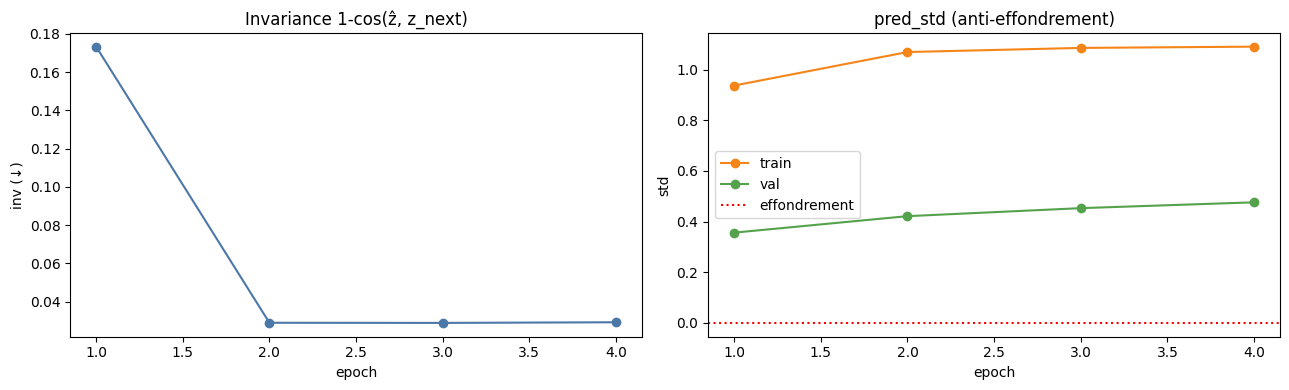

In [13]:
history = json.load(open(PROCESSED / "train_history.json"))
hist = pd.DataFrame(history)
display(hist[["epoch", "loss", "inv", "pred_std", "val_pred_std"]].round(4))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(hist["epoch"], hist["inv"], marker="o", color="#4C78A8")
a1.set(title="Invariance 1-cos(ẑ, z_next)", xlabel="epoch", ylabel="inv (↓)")
a2.plot(hist["epoch"], hist["pred_std"], marker="o", label="train", color="#F58518")
a2.plot(hist["epoch"], hist["val_pred_std"], marker="o", label="val", color="#54A24B")
a2.axhline(0, color="red", ls=":", label="effondrement")
a2.set(title="pred_std (anti-effondrement)", xlabel="epoch", ylabel="std"); a2.legend()
plt.tight_layout(); plt.show()

In [14]:
sequences, genome, maps = load_all()
model = load_model(DEVICE)
eval_sub = sequences.sample(EVAL_USERS, random_state=0).reset_index(drop=True)
print(f"modèle rechargé (epoch {torch.load(PROCESSED/'jepa.pt', map_location='cpu', weights_only=False).get('epoch','?')})")

item_bank = ev.build_item_bank(model, DEVICE)
zhat, H, T = ev.encode_eval(model, eval_sub, DEVICE, split="test")
print("item bank:", tuple(item_bank.shape), "| requêtes test:", tuple(zhat.shape))

modèle rechargé (epoch 4)
item bank: (10346, 128) | requêtes test: (7999, 128)


In [15]:
# DIAGNOSTIC CLÉ : le cosine de 0.97 est-il impressionnant ou trivial ?
diag = ev.representation_diagnostics(model, sequences, DEVICE)
print(f"Similarité cosine moyenne entre 2 chunks au hasard : {diag['mean_pairwise_cos_targets']:.3f}")
print(f"Anisotropie (norme direction moyenne, 1=tout aligné) : {diag['anisotropy_mean_dir_norm']:.3f}")
print()
print("Lecture :")
print("  - si sim ~0.9 -> l'espace des cibles est ÉTROIT : cosine 0.97 = TRIVIAL (raccourci)")
print("  - si sim ~0.2 -> cosine 0.97 = vraie prédiction discriminante")

Similarité cosine moyenne entre 2 chunks au hasard : 1.000
Anisotropie (norme direction moyenne, 1=tout aligné) : 1.000

Lecture :
  - si sim ~0.9 -> l'espace des cibles est ÉTROIT : cosine 0.97 = TRIVIAL (raccourci)
  - si sim ~0.2 -> cosine 0.97 = vraie prédiction discriminante


## 2 — Retrieval

**Films** : la représentation prédite `ẑ` retrouve-t-elle les films du vrai prochain chunk, mieux que la simple **popularité** ?

In [16]:
rf = ev.retrieval_films(zhat, item_bank, T, sequences, maps, ks=(10, 20, 50, 100), device=DEVICE)
tbl = pd.DataFrame({"JEPA": rf["recall_model"], "Popularité": rf["recall_pop"]})
tbl.index.name = "Recall@K"
display((tbl * 100).round(2).astype(str) + " %")
print("Rang médian du 1er bon film (JEPA) :", rf["median_rank_model"])

,JEPA,Popularité
Recall@K,,
10,0.64 %,11.18 %
20,1.69 %,17.7 %
50,4.66 %,30.97 %
100,9.66 %,43.37 %


Rang médian du 1er bon film (JEPA) : 100.0


**Chunks** : plus proche voisin de `ẑ` parmi les vrais chunks de test, vs baseline **répétition** (redonner le dernier chunk vu).

In [17]:
rc = ev.retrieval_chunks(model, zhat, eval_sub, maps, DEVICE, ks=(1, 5, 10, 20))
tblc = pd.DataFrame({"JEPA": rc["recall_model"], "Répétition": rc["recall_repeat"]})
tblc.index.name = f"Recall@K (parmi {rc['n']} chunks)"
display((tblc * 100).round(2).astype(str) + " %")

,JEPA,Répétition
Recall@K (parmi 7999 chunks),,
1,0.0 %,0.0 %
5,0.01 %,0.03 %
10,0.04 %,0.11 %
20,0.24 %,0.28 %


## 3 — Probes de contenu

L'état de contexte `hₜ` encode-t-il le **contenu** du prochain chunk ? (régression genome R², classification genres AUC)

In [18]:
r2 = ev.probe_genome(H, T, genome)
auc, genres_used = ev.probe_genres(H, T, maps)
print(f"Probe genome (R², variance expliquée du genome futur) : {r2:.3f}")
print(f"Probe genres (AUC macro, {len(genres_used)} genres)          : {auc:.3f}")
print("  (R² et AUC ~0 / 0.5 = l'espace n'encode PAS le contenu ; élevé = il le capte)")

Probe genome (R², variance expliquée du genome futur) : 0.048
Probe genres (AUC macro, 12 genres)          : 0.550
  (R² et AUC ~0 / 0.5 = l'espace n'encode PAS le contenu ; élevé = il le capte)


**UMAP** — projection 2D des représentations de chunk, colorée par genre dominant. Si l'espace est structuré, les genres se regroupent.

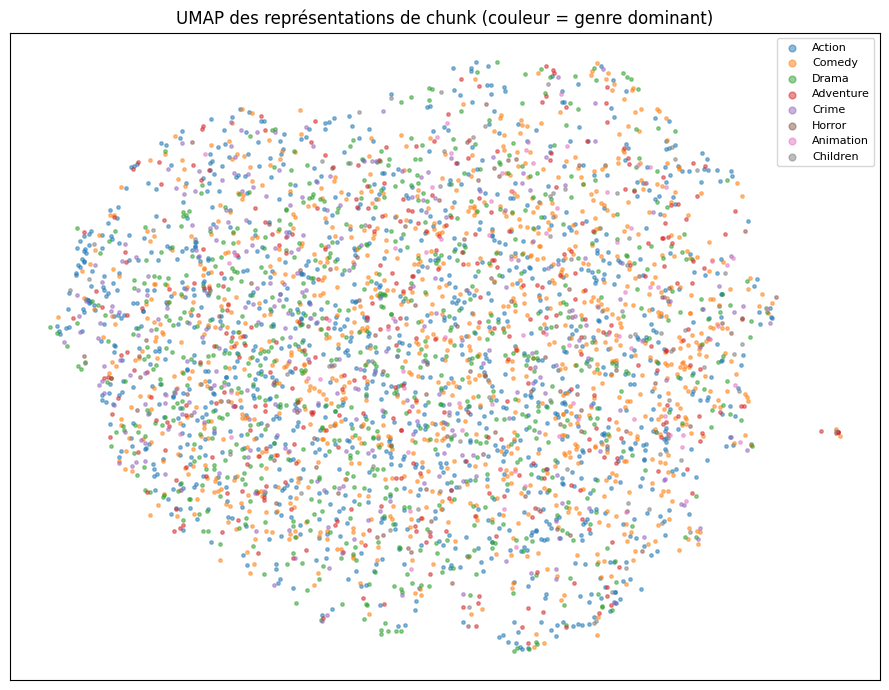

In [21]:
proj, gen = ev.umap_chunks(model, sequences, maps, DEVICE, n_chunks=4000)
gen = np.array(gen)
top = pd.Series(gen).value_counts().head(8).index.tolist()
plt.figure(figsize=(9, 7))
for g in top:
    m = gen == g
    plt.scatter(proj[m, 0], proj[m, 1], s=6, alpha=0.5, label=g)
plt.legend(markerscale=2, fontsize=8, loc="best")
plt.title("UMAP des représentations de chunk (couleur = genre dominant)")
plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

## Verdict POC (à lire honnêtement)

Grille de lecture :

- **Anti-effondrement** : `pred_std` reste franchement > 0 → le modèle n'a pas triché.
- **Retrieval films vs popularité** : si JEPA **> popularité**, il a appris quelque chose d'utile au-delà du « recommander les blockbusters ». S'il reste **sous** la popularité, le signal séquentiel appris est faible (fréquent sur MovieLens à cause des rafales de notation).
- **Retrieval chunks vs répétition** : si JEPA **> répétition**, il anticipe un changement plutôt que de recopier le passé immédiat.
- **Probes** : R²/AUC élevés → l'espace latent code le contenu futur = une vraie forme de *compréhension* de trajectoire, même si le retrieval brut est modeste.

Le cas le plus instructif d'une POC : **probes bons mais retrieval ≈ popularité** → le JEPA capte la *structure* du goût sans battre une heuristique triviale de reco. À interpréter ensemble.